In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [2]:
def get_results(mod, v):
    preds = []
    for vid in test_vids:
        p = np.load(mod_base.format(mod, v, vid))
        p = p.argmax(axis=1)
        preds += list(p)
    preds = np.array(preds)
    return preds

In [3]:
test_vids = [
    'churchlandlab_CSHL045_2020-02-27-001',
    'cortexlab_KS020_2020-02-06-001',
    'hoferlab_SWC_043_2020-09-15-001',
    'mrsicflogellab_SWC_052_2020-10-22-001',
    'wittenlab_ibl_witten_27_2021-01-21-001',
]
label_names = ['avg', 'still', 'move', 'wheel_turn', 'groom']

In [4]:
# load gt labels
base = '/home/bsb2144/daart_utils/data/ibl/labels-hand/{}_labels.csv'
labels = {}
states = []
for vid in test_vids:
    labs = pd.read_csv(base.format(vid),index_col=0).to_numpy()
    labs = labs.argmax(axis=1)
    states += list(labs)
    labels[vid] = labs
states = np.array(states)

In [7]:
# f1 dict
mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-1-good_sample-{}_markers/version_0/{}_states.npy'
f1_meta = {}

In [8]:
# reg model
mods = ['nope', 'all', 'rotate', 'shift', 'gauss', 'shot']

for mod in mods:
    f1_meta[mod] = []
    for v in range(1):
        preds = get_results(mod,v)
        f1 = f1_score(states[states>0], preds[states>0], average=None)
        f1_meta[mod].append([np.mean(f1)] + list(f1))

In [9]:
# aggregate results
f1_plot = {}
for mod in mods:
    mean_list = []
    sd_list = []
    for p in range(len(labels)):
        mean = np.mean([a[p] for a in f1_meta[mod]])
        sd = np.std([a[p] for a in f1_meta[mod]])/5
        mean_list.append(mean)
        sd_list.append(sd)
    f1_plot[mod] = (mean_list, sd_list)
        

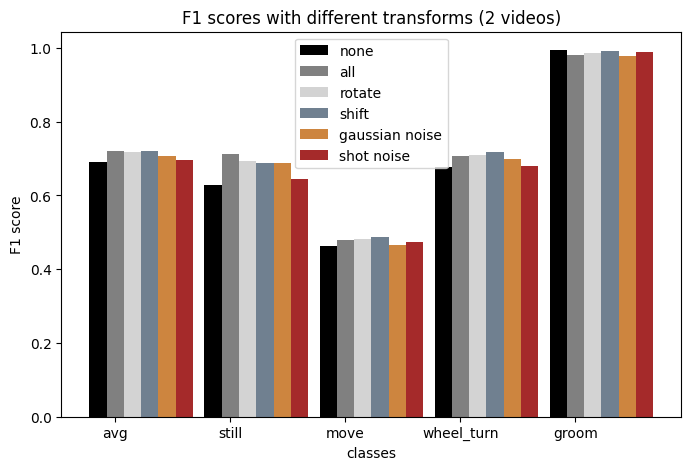

In [12]:
# Numbers of pairs of bars you want
N = len(label_names)
# Position of bars on x-axis
ind = np.arange(N)
m_l = ['none', 'all', 'rotate', 'shift', 'gaussian noise', 'shot noise']
colors = ['black', 'grey', 'lightgrey', 'slategrey', 'peru', 'brown']
# Figure size
plt.figure(figsize=(8,5))

# Width of a bar 
width = 0.15     
i=0
for mod, (mean, sd) in f1_plot.items():
    # Plotting
    plt.bar(ind + width*i, mean, width, label=m_l[i], color=colors[i],yerr=sd)
    plt.xlabel('classes')
    plt.ylabel('F1 score')
    plt.title('F1 scores with different transforms (2 videos)')

    # xticks()
    # First argument - A list of positions at which ticks should be placed
    # Second argument -  A list of labels to place at the given locations
    plt.xticks(ind + width, label_names)
    i+=1
    
# Finding the best position for legends and putting it
plt.legend(loc='best')
plt.show()
